# AI Nutrient Analysis Model

**Author:** Afsa Umutoniwase  
**Project:** FarmSmart Hydroponics System  
**Date:** 2026

Training notebook for Random Forest classifier that predicts nutrient adjustments based on sensor data.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import json
import os
from pathlib import Path

warnings.filterwarnings('ignore')

# Automatically detect the notebook's location and set directories
BASE_DIR = Path(os.getcwd())

# If running from project root, navigate to model folder
if 'Models' not in str(BASE_DIR):
    BASE_DIR = BASE_DIR / 'Models' / 'ai_nutrient_analysis'
elif BASE_DIR.name != 'ai_nutrient_analysis':
    BASE_DIR = BASE_DIR / 'ai_nutrient_analysis'

# Store all results in the same directory as the notebook
RESULTS_DIR = BASE_DIR
RESULTS_DIR.mkdir(exist_ok=True)

# Find project root (2 levels up from ai_nutrient_analysis)
PROJECT_ROOT = BASE_DIR.parent.parent

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")
print(f"Working directory: {BASE_DIR}")
print(f"Results will be saved to: {RESULTS_DIR}")
print(f"Project root: {PROJECT_ROOT}")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start(

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start(

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Libraries imported successfully!
Working directory: c:\Users\HP\Desktop\ALU\Front-end\FarmSmart\Models\ai_nutrient_analysis
Results will be saved to: c:\Users\HP\Desktop\ALU\Front-end\FarmSmart\Models\ai_nutrient_analysis
Project root: c:\Users\HP\Desktop\ALU\Front-end\FarmSmart


## 1. Data Loading and Exploration


In [2]:
# Load IoT Sensor Data (Kaggle)
print("IoT DATA (Kaggle - Sensor & Actuator Logs)")

# Build path to Kaggle data from project root
data_path = PROJECT_ROOT / 'Models' / 'Kaggle data' / 'IoTData --Raw--.csv'

if not data_path.exists():
    print(f"Error: Data file not found at {data_path}")
    print("Please ensure the data file exists in Models/Kaggle data/")
else:
    iot_data = pd.read_csv(data_path)
    print(f"IoT Data Shape: {iot_data.shape}")
    print(f"Columns: {list(iot_data.columns)}")
    print(f"\nFirst few rows:")
    display(iot_data.head())


IoT DATA (Kaggle - Sensor & Actuator Logs)
IoT Data Shape: (50570, 13)
Columns: ['id', 'timestamp', 'pH', 'TDS', 'water_level', 'DHT_temp', 'DHT_humidity', 'water_temp', 'pH_reducer', 'add_water', 'nutrients_adder', 'humidifier', 'ex_fan']

First few rows:


,id,timestamp,pH,TDS,water_level,DHT_temp,DHT_humidity,water_temp,pH_reducer,add_water,nutrients_adder,humidifier,ex_fan
0,1,2023-11-26 10:57:52,7.0,500.0,0,25.5,60.0,20.0,ON,NaN,OFF,OFF,ON
1,2,2023-11-26 10:58:37,7.0,500.0,0,25.5,60.0,20.0,ON,NaN,OFF,OFF,OFF
2,3,2023-11-26 11:01:34,7.0,500.0,3,25.5,60.0,20.0,ON,NaN,OFF,OFF,OFF
3,4,2023-12-05 11:30:58,7.0,500.0,3,25.5,60.0,20.0,ON,NaN,OFF,OFF,OFF
4,5,2023-12-05 11:33:50,7.0,500.0,3,25.5,60.0,20.0,ON,ON,OFF,OFF,OFF


In [3]:
# Data Overview
print("DATASET OVERVIEW")
print(f"\n1. IoT Data (Kaggle Repository):")
print(f"   - Source: Hydroponics IoT Sensor & Actuator Logs")
print(f"   - Records: {len(iot_data):,}")
print(f"   - Columns: {iot_data.shape[1]}")
print(f"   - Key Features: pH, TDS (to EC), Temperature, Actuator States")
print(f"   - Missing Values: {iot_data.isnull().sum().sum()}")

print(f"\n2. Synthetic Data (Rwanda Context):")
print(f"   - Records: 5,000 (to be generated)")
print(f"   - Based on: Oklahoma State University Extension standards")
print(f"   - Calibrated with: Meteo Rwanda climate data")

print("\nDATASET STRATEGY")
print("This project uses IoT sensor data and localized synthetic data (Rwanda context).")


DATASET OVERVIEW

1. IoT Data (Kaggle Repository):
   - Source: Hydroponics IoT Sensor & Actuator Logs
   - Records: 50,570
   - Columns: 13
   - Key Features: pH, TDS (to EC), Temperature, Actuator States
   - Missing Values: 4

2. Synthetic Data (Rwanda Context):
   - Records: 5,000 (to be generated)
   - Based on: Oklahoma State University Extension standards
   - Calibrated with: Meteo Rwanda climate data

DATASET STRATEGY
This project uses IoT sensor data and localized synthetic data (Rwanda context).


## 2. Data Engineering


In [4]:
print("Processing IoT Data...")
print(f"Original IoT Data Shape: {iot_data.shape}")

iot_processed = iot_data.copy()
iot_processed['pH'] = pd.to_numeric(iot_processed['pH'], errors='coerce')
iot_processed['TDS'] = pd.to_numeric(iot_processed['TDS'], errors='coerce')
iot_processed['DHT_temp'] = pd.to_numeric(iot_processed['DHT_temp'], errors='coerce')

iot_processed['EC_Value'] = iot_processed['TDS'] / 500  # Convert TDS to EC (mS/cm)
iot_processed['pH_Level'] = iot_processed['pH']
iot_processed['Ambient_Temp'] = iot_processed['DHT_temp']

def create_target_action(row):
    """Create target action label based on actuator states and pH/EC levels"""
def create_target_action(row):
    """Create target action label based on actuator states and pH/EC levels"""
    if pd.notna(row['pH_Level']):
        if row['pH_Level'] > 7.0:
            return 'Add_pH_Down'
        elif row['pH_Level'] < 5.0:
            return 'Add_pH_Up'
    
    if pd.notna(row['EC_Value']):
        if row['EC_Value'] > 3.0:
            return 'Dilute'
        elif row['EC_Value'] < 1.0:
            return 'Add_Nutrients'
    
    if pd.notna(row.get('pH_reducer')) and str(row.get('pH_reducer', '')).upper() == 'ON':
        return 'Add_pH_Down'
    if pd.notna(row.get('nutrients_adder')) and str(row.get('nutrients_adder', '')).upper() == 'ON':
        return 'Add_Nutrients'
    if pd.notna(row.get('add_water')) and str(row.get('add_water', '')).upper() == 'ON':
        return 'Dilute'
    
    return 'Maintain'

iot_processed['Target_Action'] = iot_processed.apply(create_target_action, axis=1)

iot_final = iot_processed[['pH_Level', 'EC_Value', 'Ambient_Temp', 'Target_Action']].copy()
iot_final = iot_final.dropna(subset=['pH_Level', 'EC_Value', 'Ambient_Temp'])

iot_final = iot_processed[['pH_Level', 'EC_Value', 'Ambient_Temp', 'Target_Action']].copy()
iot_final = iot_final.dropna(subset=['pH_Level', 'EC_Value', 'Ambient_Temp'])
iot_final = iot_final[
    (iot_final['pH_Level'] >= 3.0) & (iot_final['pH_Level'] <= 9.0) &
    (iot_final['EC_Value'] >= 0.1) & (iot_final['EC_Value'] <= 5.0) &
    (iot_final['Ambient_Temp'] >= 10) & (iot_final['Ambient_Temp'] <= 40)
]

print(f"Processed IoT Data: {iot_final.shape}")
print(f"Target Action Distribution:")
print(iot_final['Target_Action'].value_counts())
print(f"\nFirst few rows:")
iot_final.head(10)

Processing IoT Data...
Original IoT Data Shape: (50570, 13)
Processed IoT Data: (50525, 4)
Target Action Distribution:
Target_Action
Maintain         43913
Dilute            2998
Add_Nutrients     2755
Add_pH_Down        613
Add_pH_Up          246
Name: count, dtype: int64

First few rows:


,pH_Level,EC_Value,Ambient_Temp,Target_Action
0,7.00,1.0,25.5,Add_pH_Down
1,7.00,1.0,25.5,Add_pH_Down
2,7.00,1.0,25.5,Add_pH_Down
3,7.00,1.0,25.5,Add_pH_Down
4,7.00,1.0,25.5,Add_pH_Down
5,7.00,1.0,25.5,Add_pH_Down
6,5.67,1.0,25.5,Add_pH_Down
7,5.71,1.0,25.5,Add_pH_Down
8,5.66,1.0,25.5,Add_pH_Down
9,5.71,1.0,25.5,Add_pH_Down


In [5]:
print("Generating Synthetic Data for Rwanda Context...")
print("Based on Oklahoma State University Extension nutrient standards")
print("Calibrated with Rwanda climate data (Meteo Rwanda, 2025)")

np.random.seed(42)
n_synthetic = 5000

crops = ['Lettuce', 'Peppers', 'Tomatoes']
synthetic_data = []
crop_optimal_ranges = {
    'Lettuce': {'ph_min': 5.5, 'ph_max': 6.5, 'ec_min': 1.2, 'ec_max': 2.0},
    'Peppers': {'ph_min': 5.8, 'ph_max': 6.8, 'ec_min': 2.0, 'ec_max': 3.0},
    'Tomatoes': {'ph_min': 5.5, 'ph_max': 6.5, 'ec_min': 2.0, 'ec_max': 3.5}
}

scenarios = ['optimal', 'high_ph', 'low_ph', 'high_ec', 'low_ec', 'mixed']
scenario_weights = [0.4, 0.15, 0.15, 0.15, 0.1, 0.05]  # 40% optimal, rest problematic

for i in range(n_synthetic):
    crop = np.random.choice(crops)
    scenario = np.random.choice(scenarios, p=scenario_weights)
    ranges = crop_optimal_ranges[crop]
    
    if scenario == 'optimal':
        ph = np.random.uniform(ranges['ph_min'], ranges['ph_max'])
        ec = np.random.uniform(ranges['ec_min'], ranges['ec_max'])
        action = 'Maintain'
    elif scenario == 'high_ph':
        ph = np.random.uniform(7.0, 8.5)
        ec = np.random.uniform(ranges['ec_min'], ranges['ec_max'])
        action = 'Add_pH_Down'
    elif scenario == 'low_ph':
        ph = np.random.uniform(ranges['ph_min'], ranges['ph_max'])
        ec = np.random.uniform(ranges['ec_min'], ranges['ec_max'])
        action = 'Maintain'
    elif scenario == 'high_ph':
        ph = np.random.uniform(7.0, 8.5)
        ec = np.random.uniform(ranges['ec_min'], ranges['ec_max'])
        action = 'Add_pH_Down'
    elif scenario == 'low_ph':
        ph = np.random.uniform(4.0, 5.0)
        ec = np.random.uniform(ranges['ec_min'], ranges['ec_max'])
        action = 'Add_pH_Up'
    elif scenario == 'high_ec':
        ph = np.random.uniform(ranges['ph_min'], ranges['ph_max'])
        ec = np.random.uniform(3.0, 4.0)
        action = 'Dilute'
    elif scenario == 'low_ec':
        ec = np.random.uniform(0.5, 4.0)
        ec = np.random.uniform(0.5, 1.0)
        action = 'Add_Nutrients'
    else:
        ph = np.random.uniform(4.0, 8.5)
        ec = np.random.uniform(0.5, 4.0)
        if ph > 7.0:
            action = 'Add_pH_Down'
        elif ph < 5.0:
            action = 'Add_pH_Up'
        elif ec > 3.0:
            action = 'Dilute'
        elif ec < 1.0:
            action = 'Add_Nutrients'
        else:
            action = 'Maintain'
    
    ph_noise = np.random.uniform(-0.2, 0.2)
    ec_noise = np.random.uniform(-0.2, 0.2)
    ph = ph + ph_noise
    ec = ec + ec_noise
    
    ph_noise = np.random.uniform(-0.2, 0.2)
    ec_noise = np.random.uniform(-0.2, 0.2)
    ph = ph + ph_noise
    ec = ec + ec_noise
    
    ph = np.clip(ph, 4.0, 8.5)
    ec = np.clip(ec, 0.5, 4.0)
    
    temp = np.random.normal(23, 4)
    temp = np.clip(temp, 15, 32)
    
    synthetic_data.append({
        'Crop_ID': crop,
        'pH_Level': round(ph, 1),
        'EC_Value': round(ec, 2),
        'Ambient_Temp': round(temp, 1),
        'Target_Action': action
    })

synthetic_df = pd.DataFrame(synthetic_data)
print(f"\nSynthetic Data Generated: {synthetic_df.shape}")
print(f"\nSynthetic Data Summary:")
print(synthetic_df.describe())

Generating Synthetic Data for Rwanda Context...
Based on Oklahoma State University Extension nutrient standards
Calibrated with Rwanda climate data (Meteo Rwanda, 2025)

Synthetic Data Generated: (5000, 5)

Synthetic Data Summary:
         pH_Level     EC_Value  Ambient_Temp
count  5000.00000  5000.000000   5000.000000
mean      6.39016     2.312866     23.016760
std       0.78333     0.881457      3.803832
min       4.00000     0.500000     15.000000
25%       5.90000     1.660000     20.400000
50%       6.20000     2.350000     23.000000
75%       6.60000     2.990000     25.600000
max       8.50000     4.000000     32.000000


In [6]:
print("MERGING DATASETS")

def assign_crop_from_conditions(row):
    ph = row['pH_Level']
    ec = row['EC_Value']
    if 1.0 <= ec <= 2.5 and 5.5 <= ph <= 6.5:
        return 'Lettuce'
    elif 2.0 <= ec <= 3.5 and 5.8 <= ph <= 6.8:
        return 'Peppers'
    elif 2.5 <= ec <= 4.0 and 5.5 <= ph <= 6.5:
        return 'Tomatoes'
    else:
        if ec < 2.0:
            return 'Lettuce'
        elif ec < 3.0:
            return 'Peppers'
        else:
            return 'Tomatoes'

iot_final['Crop_ID'] = iot_final.apply(assign_crop_from_conditions, axis=1)

print(f"\n1. IoT Data (Kaggle): {len(iot_final):,} records")
print(f"2. Synthetic Data (Rwanda Context): {len(synthetic_df):,} records")

final_dataset = pd.concat([
    iot_final[['Crop_ID', 'pH_Level', 'EC_Value', 'Ambient_Temp', 'Target_Action']],
    synthetic_df
], ignore_index=True)

print("FINAL MERGED DATASET")
print(f"Total Records: {len(final_dataset):,}")
print(f"Total Columns: {final_dataset.shape[1]}")
print(f"\nTarget Action Distribution:")
print(final_dataset['Target_Action'].value_counts())
print(f"\nCrop Distribution:")
print(final_dataset['Crop_ID'].value_counts())
display(final_dataset.head(10))


MERGING DATASETS

1. IoT Data (Kaggle): 50,525 records
2. Synthetic Data (Rwanda Context): 5,000 records
FINAL MERGED DATASET
Total Records: 55,525
Total Columns: 5

Target Action Distribution:
Target_Action
Maintain         46708
Dilute            3798
Add_Nutrients     3256
Add_pH_Down       1469
Add_pH_Up          294
Name: count, dtype: int64

Crop Distribution:
Crop_ID
Lettuce     26286
Peppers     19266
Tomatoes     9973
Name: count, dtype: int64


,Crop_ID,pH_Level,EC_Value,Ambient_Temp,Target_Action
0,Lettuce,7.00,1.0,25.5,Add_pH_Down
1,Lettuce,7.00,1.0,25.5,Add_pH_Down
2,Lettuce,7.00,1.0,25.5,Add_pH_Down
3,Lettuce,7.00,1.0,25.5,Add_pH_Down
4,Lettuce,7.00,1.0,25.5,Add_pH_Down
5,Lettuce,7.00,1.0,25.5,Add_pH_Down
6,Lettuce,5.67,1.0,25.5,Add_pH_Down
7,Lettuce,5.71,1.0,25.5,Add_pH_Down
8,Lettuce,5.66,1.0,25.5,Add_pH_Down
9,Lettuce,5.71,1.0,25.5,Add_pH_Down


## 3. Data Visualization


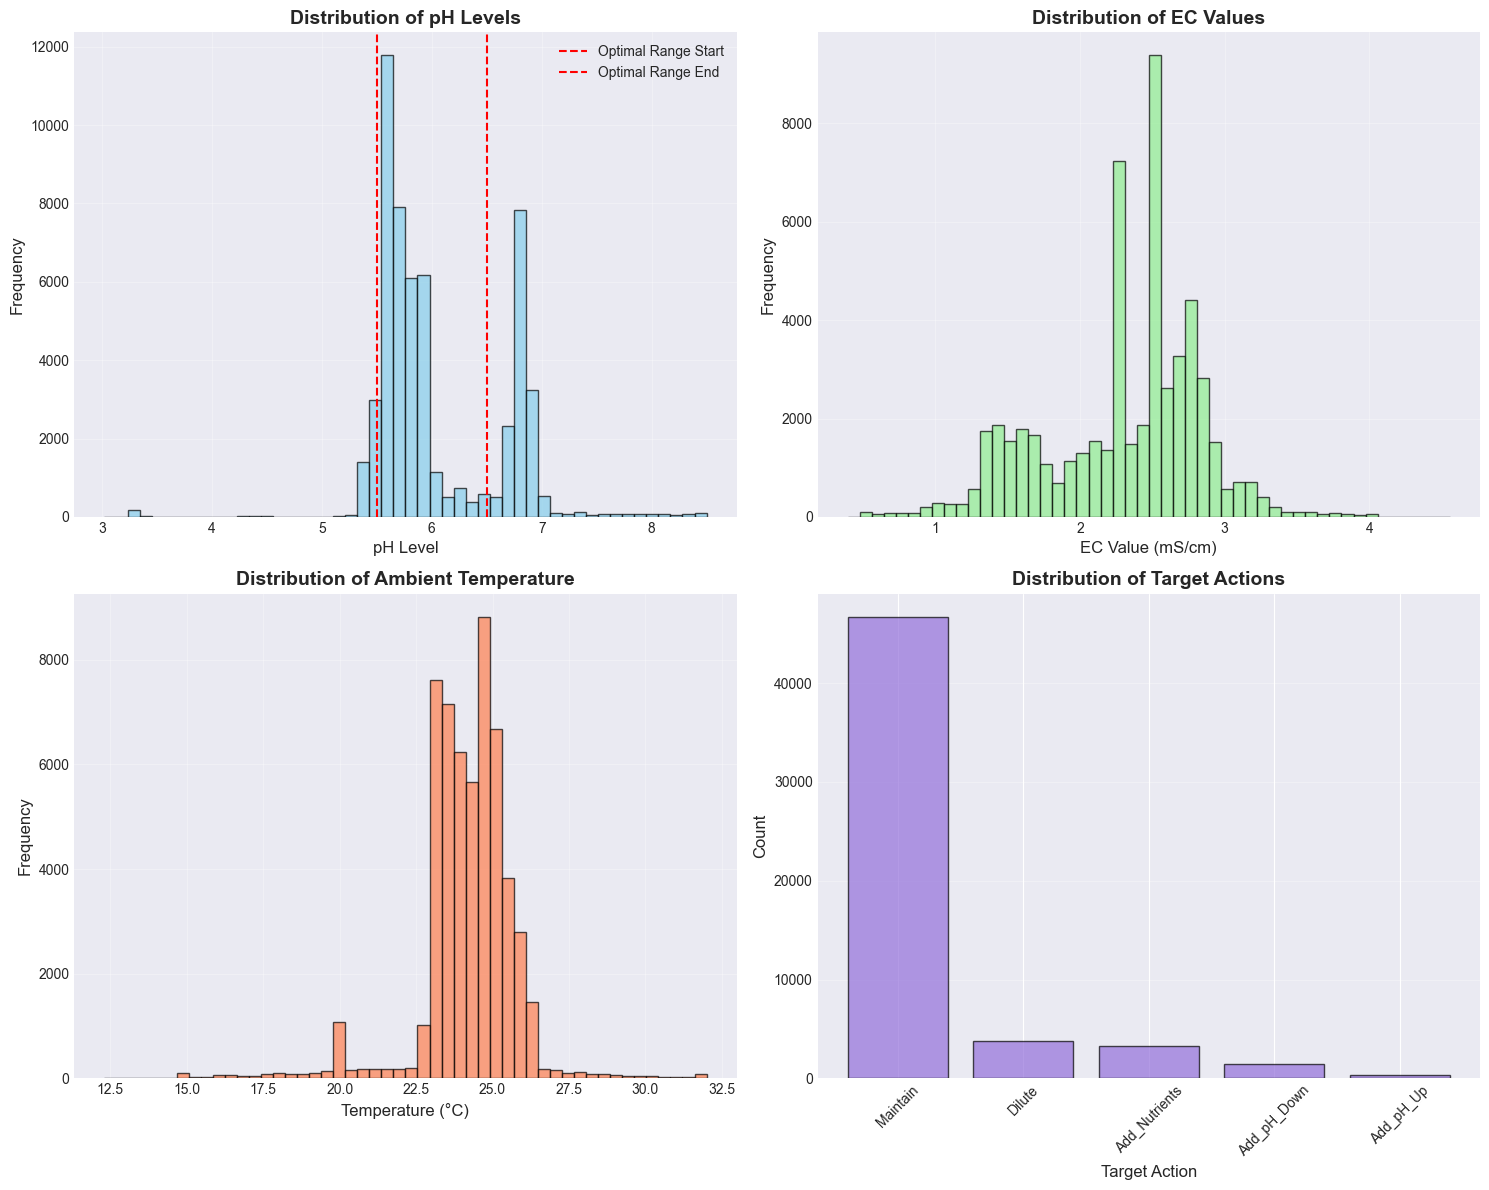

In [7]:
# 3.1 Data Distribution Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# pH Distribution
axes[0, 0].hist(final_dataset['pH_Level'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(5.5, color='red', linestyle='--', label='Optimal Range Start')
axes[0, 0].axvline(6.5, color='red', linestyle='--', label='Optimal Range End')
axes[0, 0].set_xlabel('pH Level', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of pH Levels', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# EC Distribution
axes[0, 1].hist(final_dataset['EC_Value'], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].set_xlabel('EC Value (mS/cm)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of EC Values', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Temperature Distribution
axes[1, 0].hist(final_dataset['Ambient_Temp'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Temperature (°C)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Ambient Temperature', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Target Action Distribution
action_counts = final_dataset['Target_Action'].value_counts()
axes[1, 1].bar(action_counts.index, action_counts.values, color='mediumpurple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Target Action', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].set_title('Distribution of Target Actions', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'data_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


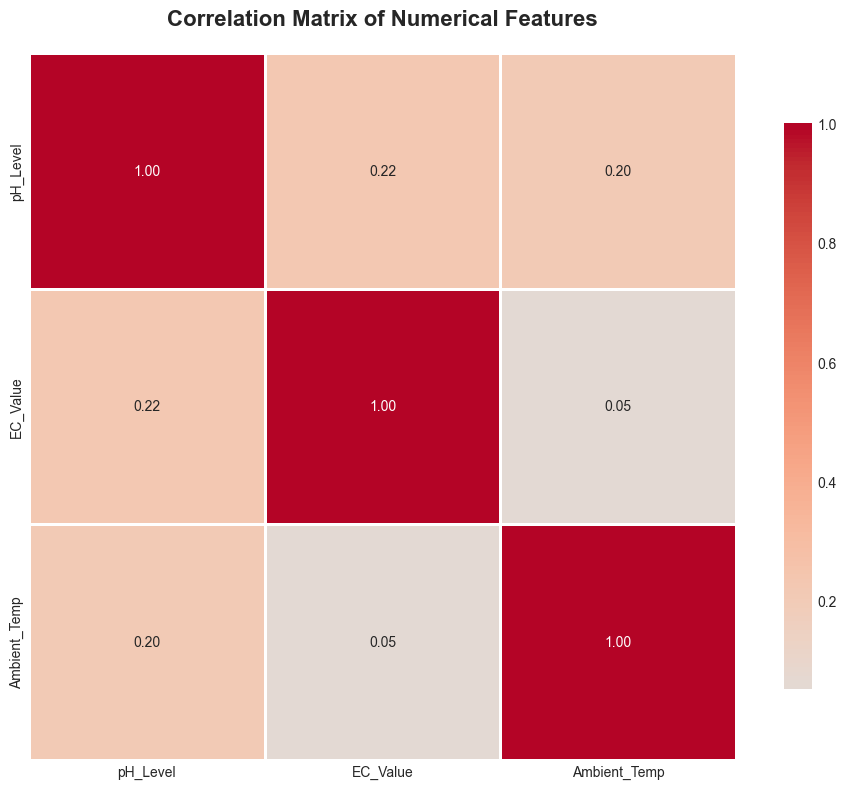

In [8]:
# 3.2 Correlation Matrix
numeric_cols = ['pH_Level', 'EC_Value', 'Ambient_Temp']
correlation_matrix = final_dataset[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(RESULTS_DIR/'correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


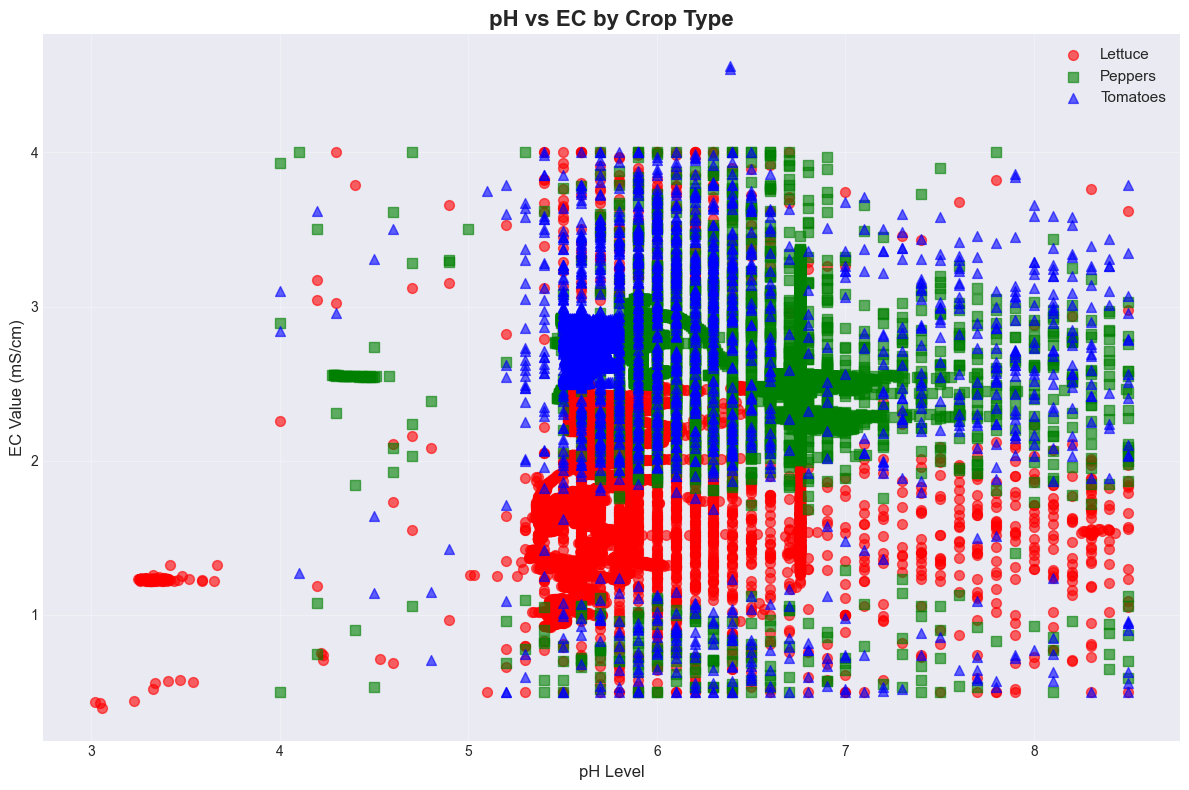

In [9]:
# 3.3 pH vs EC Scatter Plot by Crop
fig, ax = plt.subplots(figsize=(12, 8))

crops = final_dataset['Crop_ID'].unique()
colors = ['red', 'green', 'blue']
markers = ['o', 's', '^']

for crop, color, marker in zip(crops, colors, markers):
    crop_data = final_dataset[final_dataset['Crop_ID'] == crop]
    ax.scatter(crop_data['pH_Level'], crop_data['EC_Value'], 
              label=crop, alpha=0.6, s=50, color=color, marker=marker)

ax.set_xlabel('pH Level', fontsize=12)
ax.set_ylabel('EC Value (mS/cm)', fontsize=12)
ax.set_title('pH vs EC by Crop Type', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR/'ph_ec_by_crop.png', dpi=300, bbox_inches='tight')
plt.show()


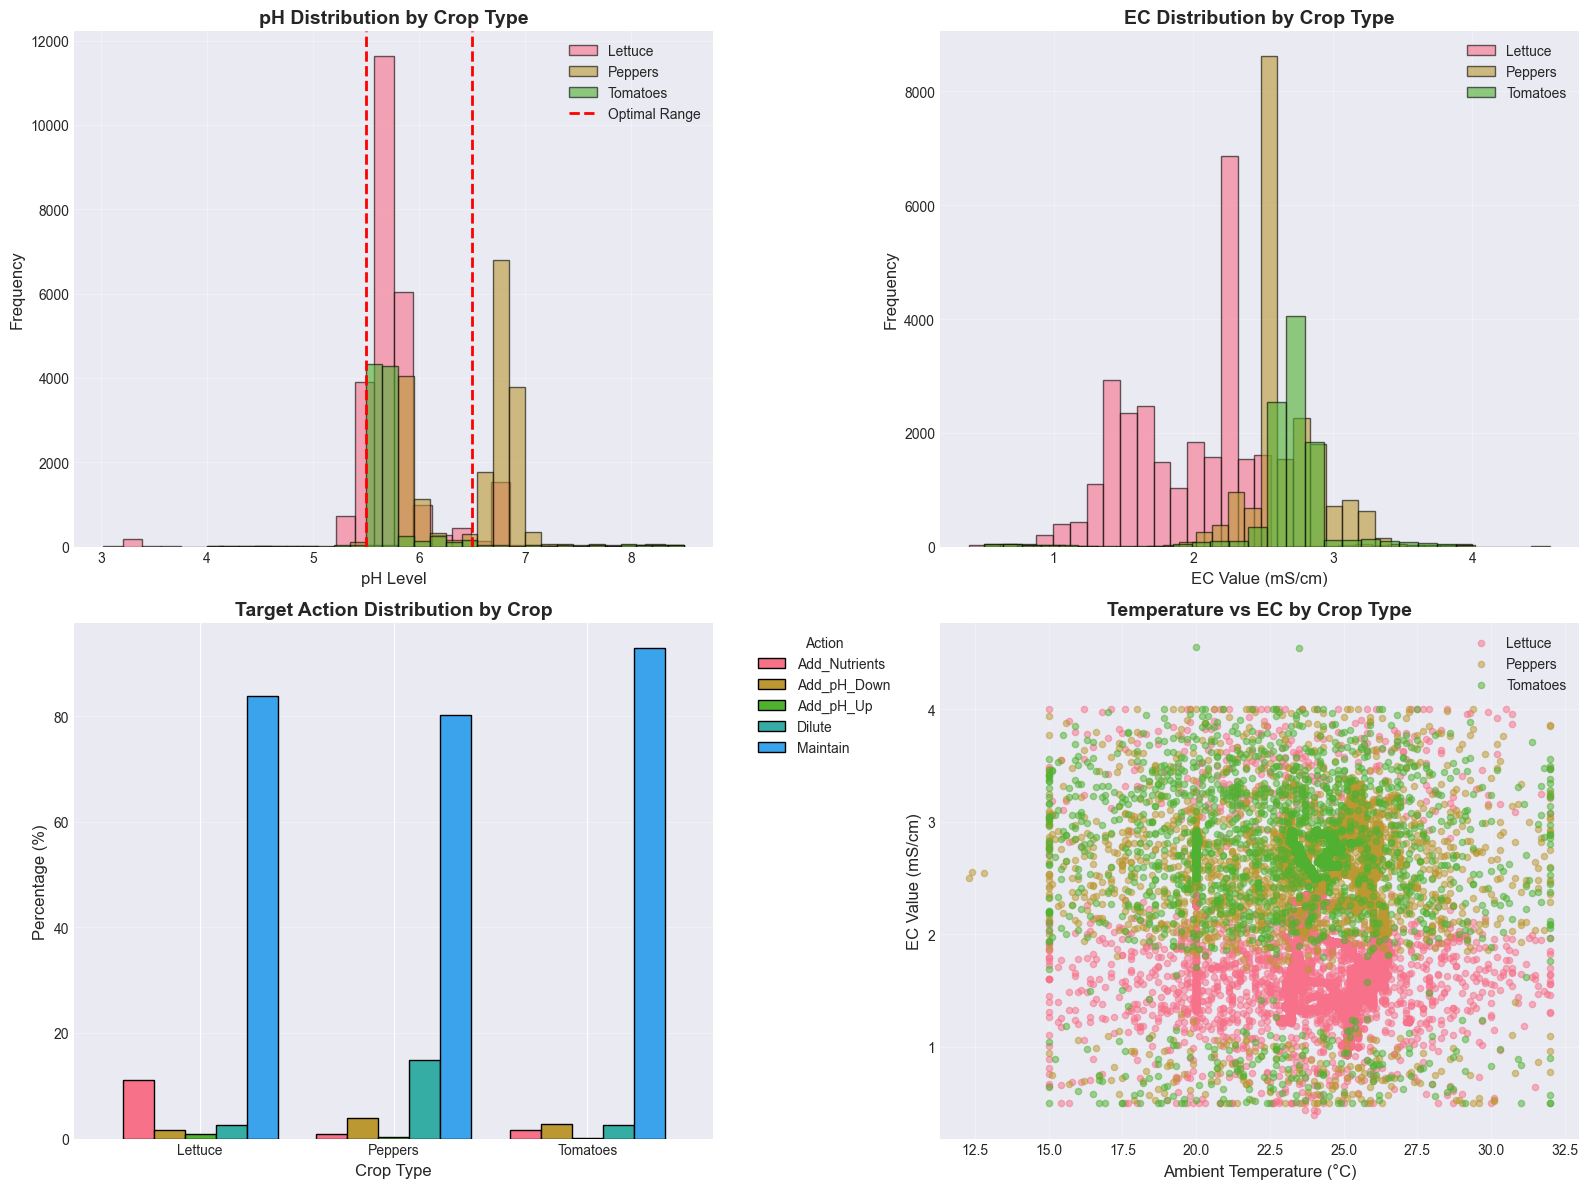

CROP-SPECIFIC STATISTICS

Lettuce:
  Count: 26,286
  pH - Mean: 5.78, Std: 0.45
  EC - Mean: 1.92, Std: 0.44
  Temp - Mean: 24.06°C, Std: 1.40°C

Peppers:
  Count: 19,266
  pH - Mean: 6.54, Std: 0.46
  EC - Mean: 2.64, Std: 0.32
  Temp - Mean: 24.59°C, Std: 1.58°C

Tomatoes:
  Count: 9,973
  pH - Mean: 5.76, Std: 0.41
  EC - Mean: 2.71, Std: 0.35
  Temp - Mean: 23.78°C, Std: 1.80°C


In [10]:
# 3.5 Crop-Specific Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# pH distribution by crop
for crop in final_dataset['Crop_ID'].unique():
    crop_data = final_dataset[final_dataset['Crop_ID'] == crop]
    axes[0, 0].hist(crop_data['pH_Level'], bins=30, alpha=0.6, label=crop, edgecolor='black')
axes[0, 0].axvline(5.5, color='red', linestyle='--', linewidth=2, label='Optimal Range')
axes[0, 0].axvline(6.5, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('pH Level', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('pH Distribution by Crop Type', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# EC distribution by crop
for crop in final_dataset['Crop_ID'].unique():
    crop_data = final_dataset[final_dataset['Crop_ID'] == crop]
    axes[0, 1].hist(crop_data['EC_Value'], bins=30, alpha=0.6, label=crop, edgecolor='black')
axes[0, 1].set_xlabel('EC Value (mS/cm)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('EC Distribution by Crop Type', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Action distribution by crop
action_by_crop = pd.crosstab(final_dataset['Crop_ID'], final_dataset['Target_Action'], normalize='index') * 100
action_by_crop.plot(kind='bar', ax=axes[1, 0], width=0.8, edgecolor='black')
axes[1, 0].set_xlabel('Crop Type', fontsize=12)
axes[1, 0].set_ylabel('Percentage (%)', fontsize=12)
axes[1, 0].set_title('Target Action Distribution by Crop', fontsize=14, fontweight='bold')
axes[1, 0].legend(title='Action', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Temperature vs EC by crop (scatter)
for crop in final_dataset['Crop_ID'].unique():
    crop_data = final_dataset[final_dataset['Crop_ID'] == crop]
    axes[1, 1].scatter(crop_data['Ambient_Temp'], crop_data['EC_Value'], 
                      alpha=0.5, label=crop, s=20)
axes[1, 1].set_xlabel('Ambient Temperature (°C)', fontsize=12)
axes[1, 1].set_ylabel('EC Value (mS/cm)', fontsize=12)
axes[1, 1].set_title('Temperature vs EC by Crop Type', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR/'crop_specific_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print crop-specific statistics
print("CROP-SPECIFIC STATISTICS")
for crop in final_dataset['Crop_ID'].unique():
    crop_data = final_dataset[final_dataset['Crop_ID'] == crop]
    print(f"\n{crop}:")
    print(f"  Count: {len(crop_data):,}")
    print(f"  pH - Mean: {crop_data['pH_Level'].mean():.2f}, Std: {crop_data['pH_Level'].std():.2f}")
    print(f"  EC - Mean: {crop_data['EC_Value'].mean():.2f}, Std: {crop_data['EC_Value'].std():.2f}")
    print(f"  Temp - Mean: {crop_data['Ambient_Temp'].mean():.2f}°C, Std: {crop_data['Ambient_Temp'].std():.2f}°C")


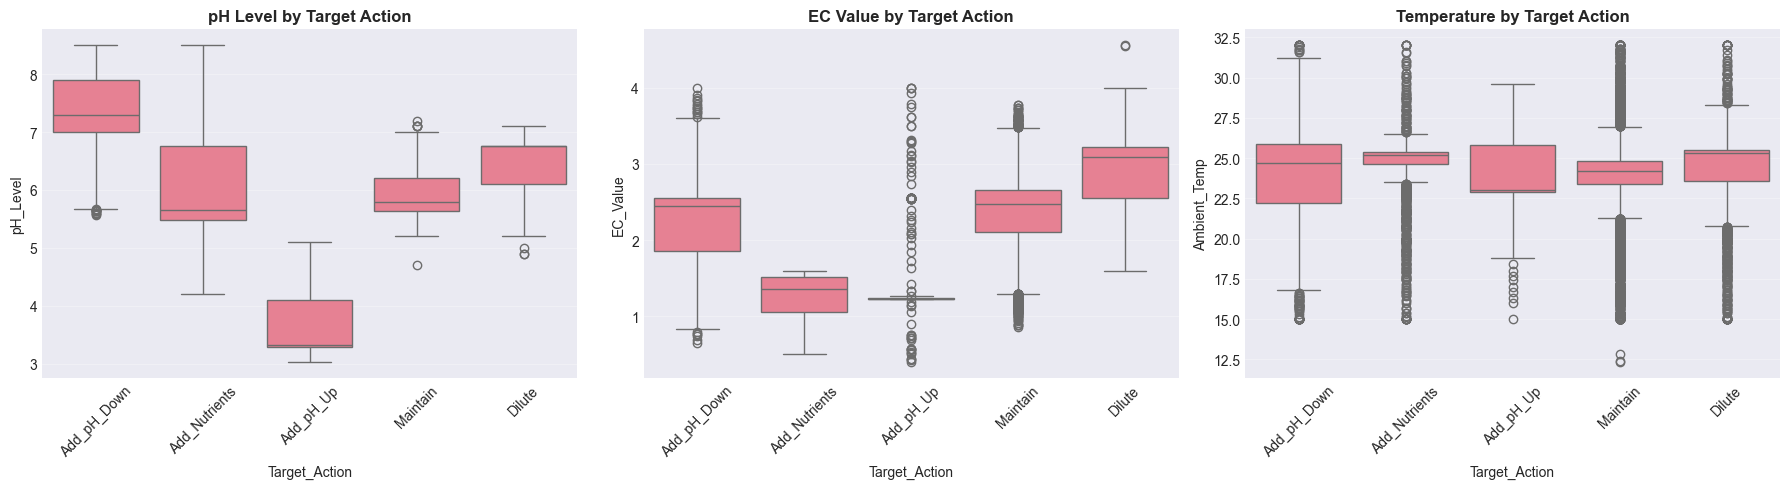

In [11]:
# 3.4 Box Plots for Feature Distributions by Target Action
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# pH by Action
sns.boxplot(data=final_dataset, x='Target_Action', y='pH_Level', ax=axes[0])
axes[0].set_title('pH Level by Target Action', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# EC by Action
sns.boxplot(data=final_dataset, x='Target_Action', y='EC_Value', ax=axes[1])
axes[1].set_title('EC Value by Target Action', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# Temperature by Action
sns.boxplot(data=final_dataset, x='Target_Action', y='Ambient_Temp', ax=axes[2])
axes[2].set_title('Temperature by Target Action', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR/'features_by_action.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Model Architecture


In [12]:
# Prepare data for modeling
print("Preparing data for ML models...")

# Encode categorical variables
le_crop = LabelEncoder()
le_action = LabelEncoder()

X = final_dataset.copy()
X['Crop_ID_encoded'] = le_crop.fit_transform(X['Crop_ID'])
X['Target_Action_encoded'] = le_action.fit_transform(X['Target_Action'])

# Features: Crop_ID, pH_Level, EC_Value, Ambient_Temp
feature_cols = ['Crop_ID_encoded', 'pH_Level', 'EC_Value', 'Ambient_Temp']
X_features = X[feature_cols]
y = X['Target_Action_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size: {X_test.shape[0]:,}")
print(f"\nFeature columns: {feature_cols}")
print(f"\nNumber of classes: {len(le_action.classes_)}")
print(f"Classes: {le_action.classes_}")


Preparing data for ML models...
Training set size: 44,420
Test set size: 11,105

Feature columns: ['Crop_ID_encoded', 'pH_Level', 'EC_Value', 'Ambient_Temp']

Number of classes: 5
Classes: ['Add_Nutrients' 'Add_pH_Down' 'Add_pH_Up' 'Dilute' 'Maintain']


### 4.1 Random Forest Classifier

- 100 decision trees
- 4 input features: Crop type, pH, EC, Temperature
- 5 output classes: Add_pH_Up, Add_pH_Down, Add_Nutrients, Dilute, Maintain

In [13]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)
print("Random Forest training completed!")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Training Random Forest Classifier...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s


Random Forest training completed!

Feature Importance:
           Feature  Importance
2         EC_Value    0.499589
1         pH_Level    0.294008
3     Ambient_Temp    0.180822
0  Crop_ID_encoded    0.025581


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.5s finished


### 4.2 Logistic Regression (Comparison)

Trained for performance comparison. Uses scaled features and multinomial classification.

In [14]:
# Train Logistic Regression (for classification comparison)
print("Training Logistic Regression Classifier...")

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial',
    solver='lbfgs'
)

lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression training completed!")


Training Logistic Regression Classifier...
Logistic Regression training completed!


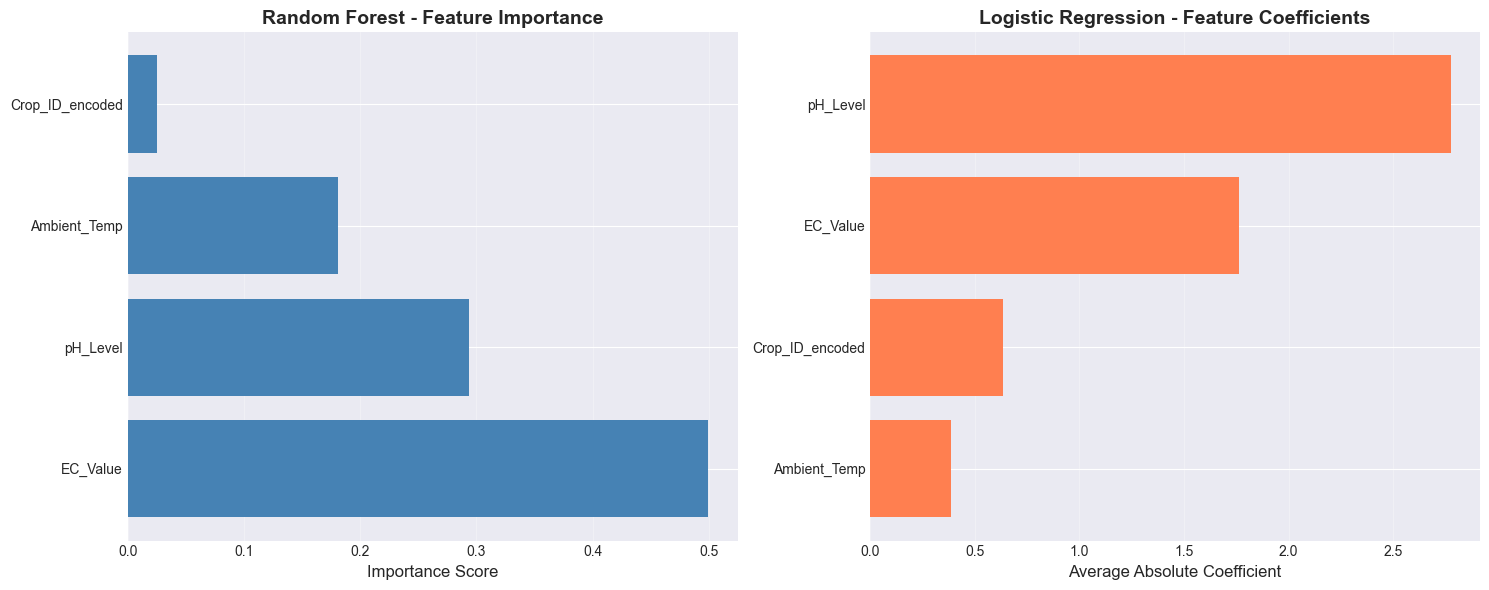

In [15]:
# Visualize Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest Feature Importance
axes[0].barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Logistic Regression Coefficients (average across classes)
lr_coef_avg = np.mean(np.abs(lr_model.coef_), axis=0)
lr_feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_coef_avg
}).sort_values('Coefficient', ascending=True)

axes[1].barh(lr_feature_importance['Feature'], lr_feature_importance['Coefficient'], color='coral')
axes[1].set_xlabel('Average Absolute Coefficient', fontsize=12)
axes[1].set_title('Logistic Regression - Feature Coefficients', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(RESULTS_DIR/'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Performance Metrics


In [16]:
# Predictions
rf_predictions = rf_model.predict(X_test)
lr_predictions = lr_model.predict(X_test_scaled)

# Get prediction probabilities
rf_proba = rf_model.predict_proba(X_test)
lr_proba = lr_model.predict_proba(X_test_scaled)

# Calculate metrics for Random Forest
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, rf_predictions, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, rf_predictions, average='weighted', zero_division=0)

# Calculate metrics for Logistic Regression
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions, average='weighted', zero_division=0)
lr_recall = recall_score(y_test, lr_predictions, average='weighted', zero_division=0)
lr_f1 = f1_score(y_test, lr_predictions, average='weighted', zero_division=0)

# Create metrics comparison
metrics_df = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [rf_accuracy, lr_accuracy],
    'Precision': [rf_precision, lr_precision],
    'Recall': [rf_recall, lr_recall],
    'F1-Score': [rf_f1, lr_f1]
})

print("PERFORMANCE METRICS COMPARISON")
print(metrics_df.to_string(index=False))
print("\n")


PERFORMANCE METRICS COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score
      Random Forest  0.986403   0.986318 0.986403  0.986324
Logistic Regression  0.932193   0.932527 0.932193  0.925632




[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


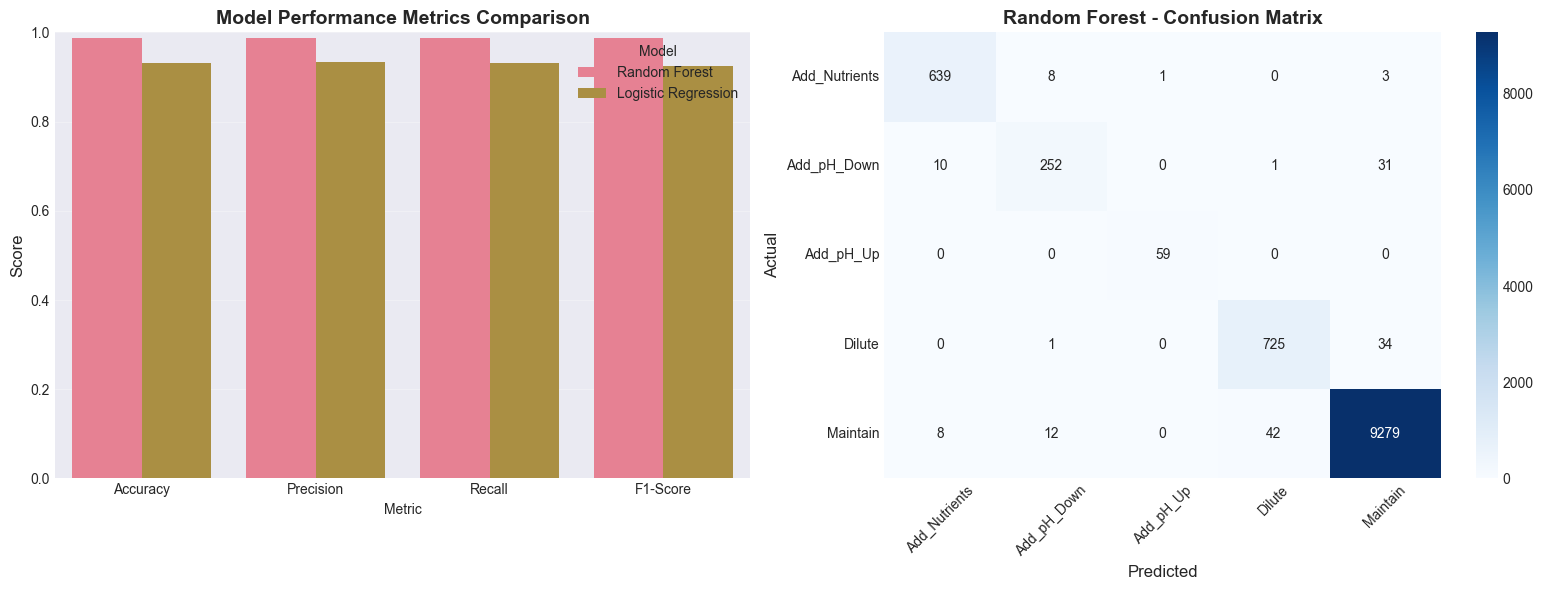

In [17]:
# Visualize Performance Metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics Comparison Bar Chart
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', ax=axes[0])
axes[0].set_title('Model Performance Metrics Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].legend(title='Model', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le_action.classes_, yticklabels=le_action.classes_)
axes[1].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR/'performance_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


In [18]:
# Detailed Classification Report
print("RANDOM FOREST - DETAILED CLASSIFICATION REPORT")
print(classification_report(y_test, rf_predictions, 
                          target_names=le_action.classes_, 
                          zero_division=0))

print("LOGISTIC REGRESSION - DETAILED CLASSIFICATION REPORT")
print(classification_report(y_test, lr_predictions, 
                          target_names=le_action.classes_, 
                          zero_division=0))


RANDOM FOREST - DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Add_Nutrients       0.97      0.98      0.98       651
  Add_pH_Down       0.92      0.86      0.89       294
    Add_pH_Up       0.98      1.00      0.99        59
       Dilute       0.94      0.95      0.95       760
     Maintain       0.99      0.99      0.99      9341

     accuracy                           0.99     11105
    macro avg       0.96      0.96      0.96     11105
 weighted avg       0.99      0.99      0.99     11105

LOGISTIC REGRESSION - DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Add_Nutrients       0.85      0.66      0.74       651
  Add_pH_Down       0.95      0.53      0.68       294
    Add_pH_Up       0.98      1.00      0.99        59
       Dilute       0.98      0.57      0.72       760
     Maintain       0.93      0.99      0.96      9341

     accuracy                           0.93     11105
    macro avg  

In [19]:
# Save models and encoders
print("Saving models and encoders...")
joblib.dump(rf_model, RESULTS_DIR/'random_forest_model.pkl')
joblib.dump(lr_model, RESULTS_DIR/'logistic_regression_model.pkl')
joblib.dump(scaler, RESULTS_DIR/'feature_scaler.pkl')
joblib.dump(le_crop, RESULTS_DIR/'crop_encoder.pkl')
joblib.dump(le_action, RESULTS_DIR/'action_encoder.pkl')

# Save metadata
metadata = {
    'feature_columns': feature_cols,
    'crop_classes': le_crop.classes_.tolist(),
    'action_classes': le_action.classes_.tolist(),
    'model_performance': {
        'random_forest': {
            'accuracy': float(rf_accuracy),
            'precision': float(rf_precision),
            'recall': float(rf_recall),
            'f1_score': float(rf_f1)
        },
        'logistic_regression': {
            'accuracy': float(lr_accuracy),
            'precision': float(lr_precision),
            'recall': float(lr_recall),
            'f1_score': float(lr_f1)
        }
    }
}

with open(RESULTS_DIR/'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Models and metadata saved successfully!")
print(f"\nBest Model: Random Forest (Accuracy: {rf_accuracy:.4f})")


Saving models and encoders...
Models and metadata saved successfully!

Best Model: Random Forest (Accuracy: 0.9864)
